In [1]:
import xarray as xr
import numpy as np
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import ffmpeg
import pylab as pl
from math import radians, cos
from matplotlib.gridspec import GridSpec

In [2]:
project='shortTime'
ed='run2/'

location='/Users/ameliaking/Proyecto/Codigo/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

var='dynDiag'

ds=xr.open_dataset(str(location) +  str(var) + '.nc')


varS='surfDiag'

dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')

#Take them minus 1 and 2 to skip the boundary
ny=len(ds.Y)
nx=len(ds.X) 
nz=len(ds.diag_levels)
nt=len(ds.T) 

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
elif project =='shortTime':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1

In [45]:
def animate(t):
    tt=((ds.T.values[t])/(60*60*24*30))
    cax0.set_array(np.ma.masked_array(T[t,:,OBp:OBendp,0],mask=mask[:,OBp:OBendp,0]))
    cax1.set_array(np.ma.masked_array(V[t,:,OBp:OBendp,0]*100,mask=masks[:,OBp:OBendp,0]))
    cax2.set_array(np.ma.masked_array(np.mean(U[t,:,OBp:OBendp,:],axis=2)*100,mask=maskw[:,OBp:OBendp,0]))
    cax3.set_array(np.ma.masked_array(W[t,:,OBp:OBendp,0]*100,mask=mask[:,OBp:OBendp,0]))
    fig.suptitle(f'After {tt:.1f} months')



In [46]:
t=40
(ds.T.values[t])/(60*60*24*30)

240.16666666666666

In [47]:
ds.T.values[40:]/(60*60*24*30)

array([240.16666667, 240.5       , 240.83333333, 241.16666667,
       241.5       , 241.83333333, 242.16666667, 242.5       ,
       242.83333333, 243.16666667, 243.5       , 243.83333333,
       244.16666667, 244.5       , 244.83333333, 245.16666667,
       245.5       , 245.83333333, 246.16666667, 246.5       ,
       246.83333333, 247.16666667, 247.5       , 247.83333333,
       248.16666667, 248.5       , 248.83333333, 249.16666667,
       249.5       , 249.83333333, 250.16666667, 250.5       ,
       250.83333333, 251.16666667, 251.5       , 251.83333333])

In [48]:
Writer = animation.writers['ffmpeg']
writer = Writer(fps=4, metadata=dict(artist='AM'), bitrate=2000)

In [49]:
params = {'font.size': 10,
          'figure.figsize': (8, 8),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [52]:
tin=4
divV=1
divU=1
divW=1

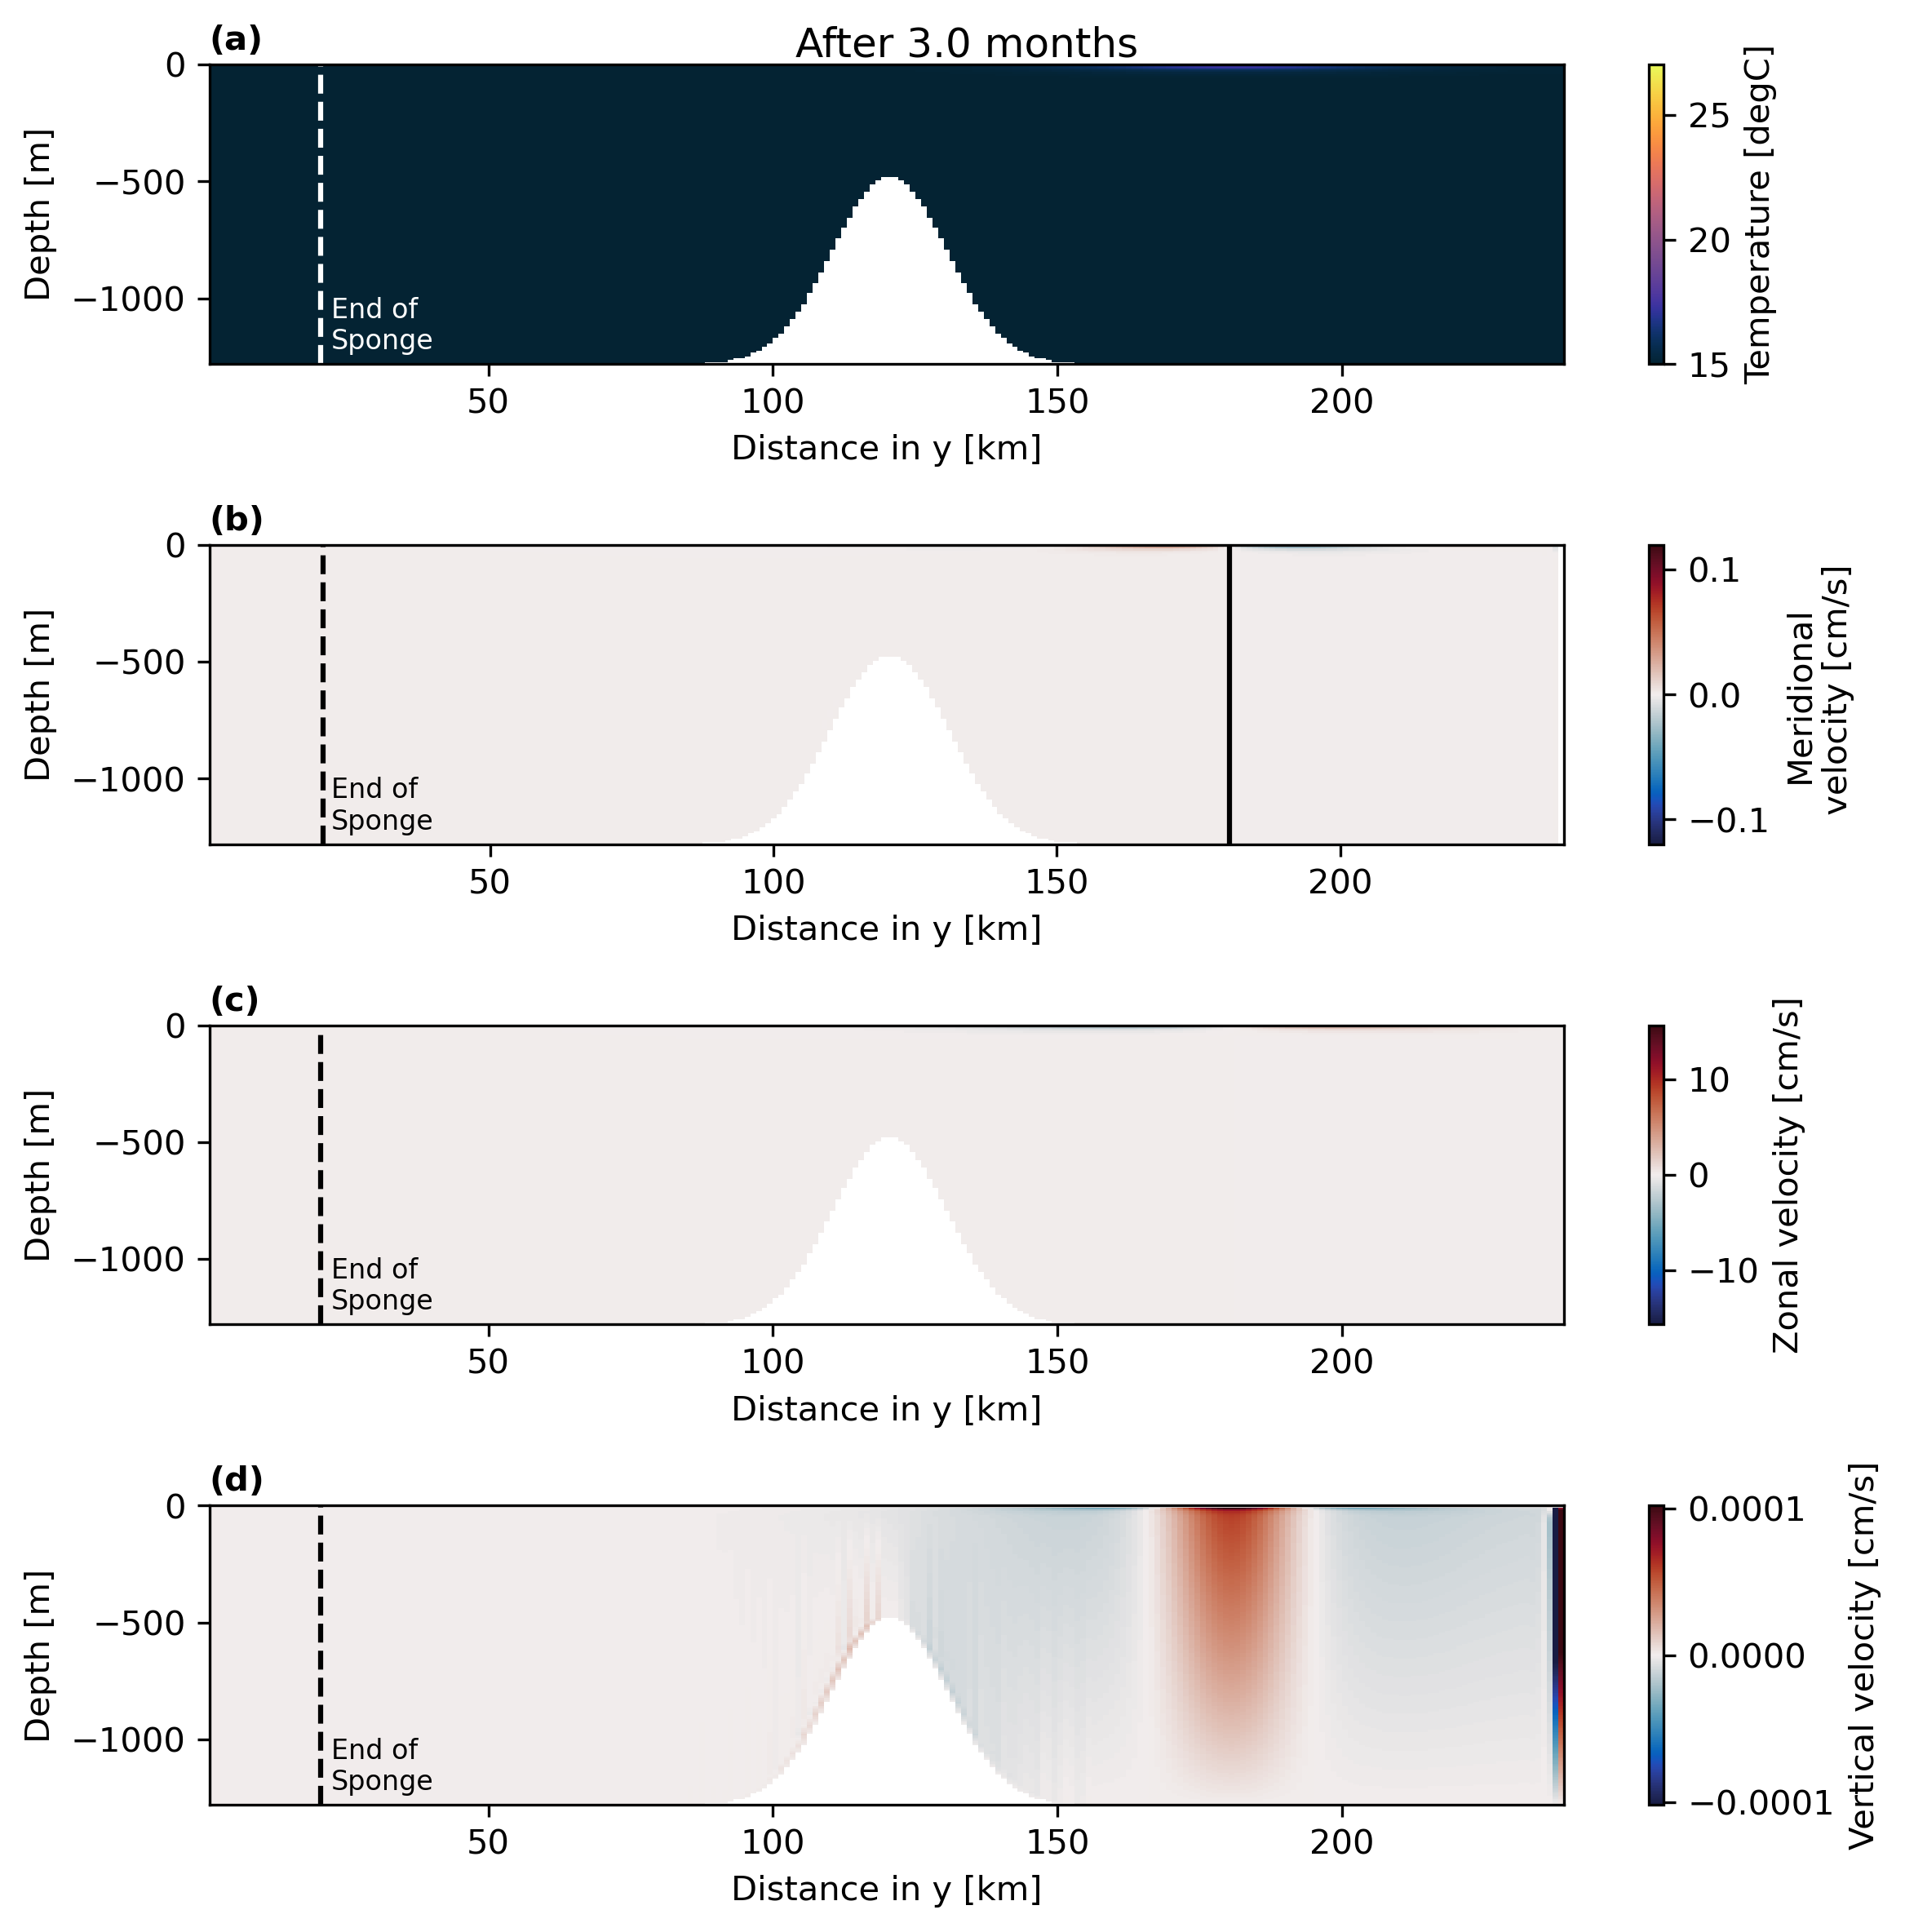

In [53]:
fig = plt.figure()
gs = GridSpec(nrows=4, ncols=1)

axin = fig.add_subplot(gs[0, 0])
axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

T=ds.THETA
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Z

vmin=np.min(np.ma.masked_array(T[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))
vmax=np.max(np.ma.masked_array(T[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))
cmapi=cmocean.cm.thermal


timein=ds.T[tin]/(60*60*24)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp,0],mask=mask[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Temperature [degC]')

axin.text(0, 1.05, '(a)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[20]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[1, 0])

V=ds.VVEL.values

title= ds.VVEL.description 
Yin=ds.Yp1[OBp:OBendp]

vmin=np.min(np.ma.masked_array(V[tin,:,OB:OBend,0]*100,mask=masks[:,OB:OBend,0]))/divV
vmax=-np.min(np.ma.masked_array(V[tin,:,OB:OBend,0]*100,mask=masks[:,OB:OBend,0]))/divV
cmapi=cmocean.cm.balance


axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax1=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(V[tin,:,OBp:OBendp,0]*100,mask=masks[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax1)
axin.axvline(ds.Y[int(0.75*ny)]/1000,c='k')
cbar_ax.set_label('Meridional\n velocity [cm/s]')




axin.text(0, 1.05, '(b)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[2, 0])

U=ds.UVEL
title= U.description 
Yin=ds.Y[OBp:OBendp]

vmin=np.min(np.ma.masked_array(np.mean(U[tin,:,OB:OBend,:],axis=2))*100)/divU
vmax=-np.min(np.ma.masked_array(np.mean(U[tin,:,OB:OBend,:],axis=2))*100)/divU
cmapi=cmocean.cm.balance



axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax2=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(np.mean(U[tin,:,OBp:OBendp,:],axis=2)*100,mask=maskw[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax2)
cbar_ax.set_label('Zonal velocity [cm/s]')


axin.text(0, 1.05, '(c)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)



W=ds.WVEL.values

title= ds.WVEL.description 
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Z

vmin=np.min(np.ma.masked_array(W[tin,:,OB:OBend,0]*100,mask=mask[:,OB:OBend,0]))/divW
vmax=-np.min(np.ma.masked_array(W[tin,:,OB:OBend,0]*100,mask=mask[:,OB:OBend,0]))/divW
cmapi=cmocean.cm.balance

axin = fig.add_subplot(gs[3, 0])

axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax3=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(W[tin,:,OBp:OBendp,0]*100,mask=mask[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax3)
cbar_ax.set_label('Vertical velocity [cm/s]')

axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

axin.text(0, 1.05, '(d)', fontweight='bold', color='k', 
        transform=axin.transAxes)

fig.tight_layout()
anim = FuncAnimation(fig, animate,frames=len(ds.T.values), repeat=False)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'crossects.mp4', writer=writer, dpi=600)


In [14]:
def BottomConc(vel, hfac, nz,nt, ny):
    '''vel: Velocity field (nt,nz,ny)
       hfac: fraction of open cell at center (nz,ny)
       
       RETURNS:
       
       BotVel = velocity near bottom (nt,ny)'''
    
    BotVel = np.empty((nt,ny))
    BottomInd = np.argmax(hfac[::-1,:]>0.0,axis=0) # start looking for first no-land cell from the bottom up.
    BottomInd = (np.ones(np.shape(BottomInd))*nz - BottomInd)-1 # Get index of unreversed z axis
    
    for j in range(nt):
        for i in range(ny): 
            BotVel[j,i] = vel[j,int(BottomInd[i]),i] 
                
    
    return (BotVel)


In [9]:
velout=BottomConc(V[:,:,:,0],hFacS[:,:,0].values , nz, nt, ny+1)

In [10]:
params = {'font.size': 10,
          'figure.figsize': (8, 4),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [11]:
tinmerid=0

In [12]:
def animateLine(t):
    tt=(t+1+tinmerid)*((ds.T.values[1]-ds.T.values[0])/(60*60*24))
    pax.set_ydata(velout[t+tinmerid,OB:OBend]*100)
    fig.suptitle(f'After {tt:.1f} days')


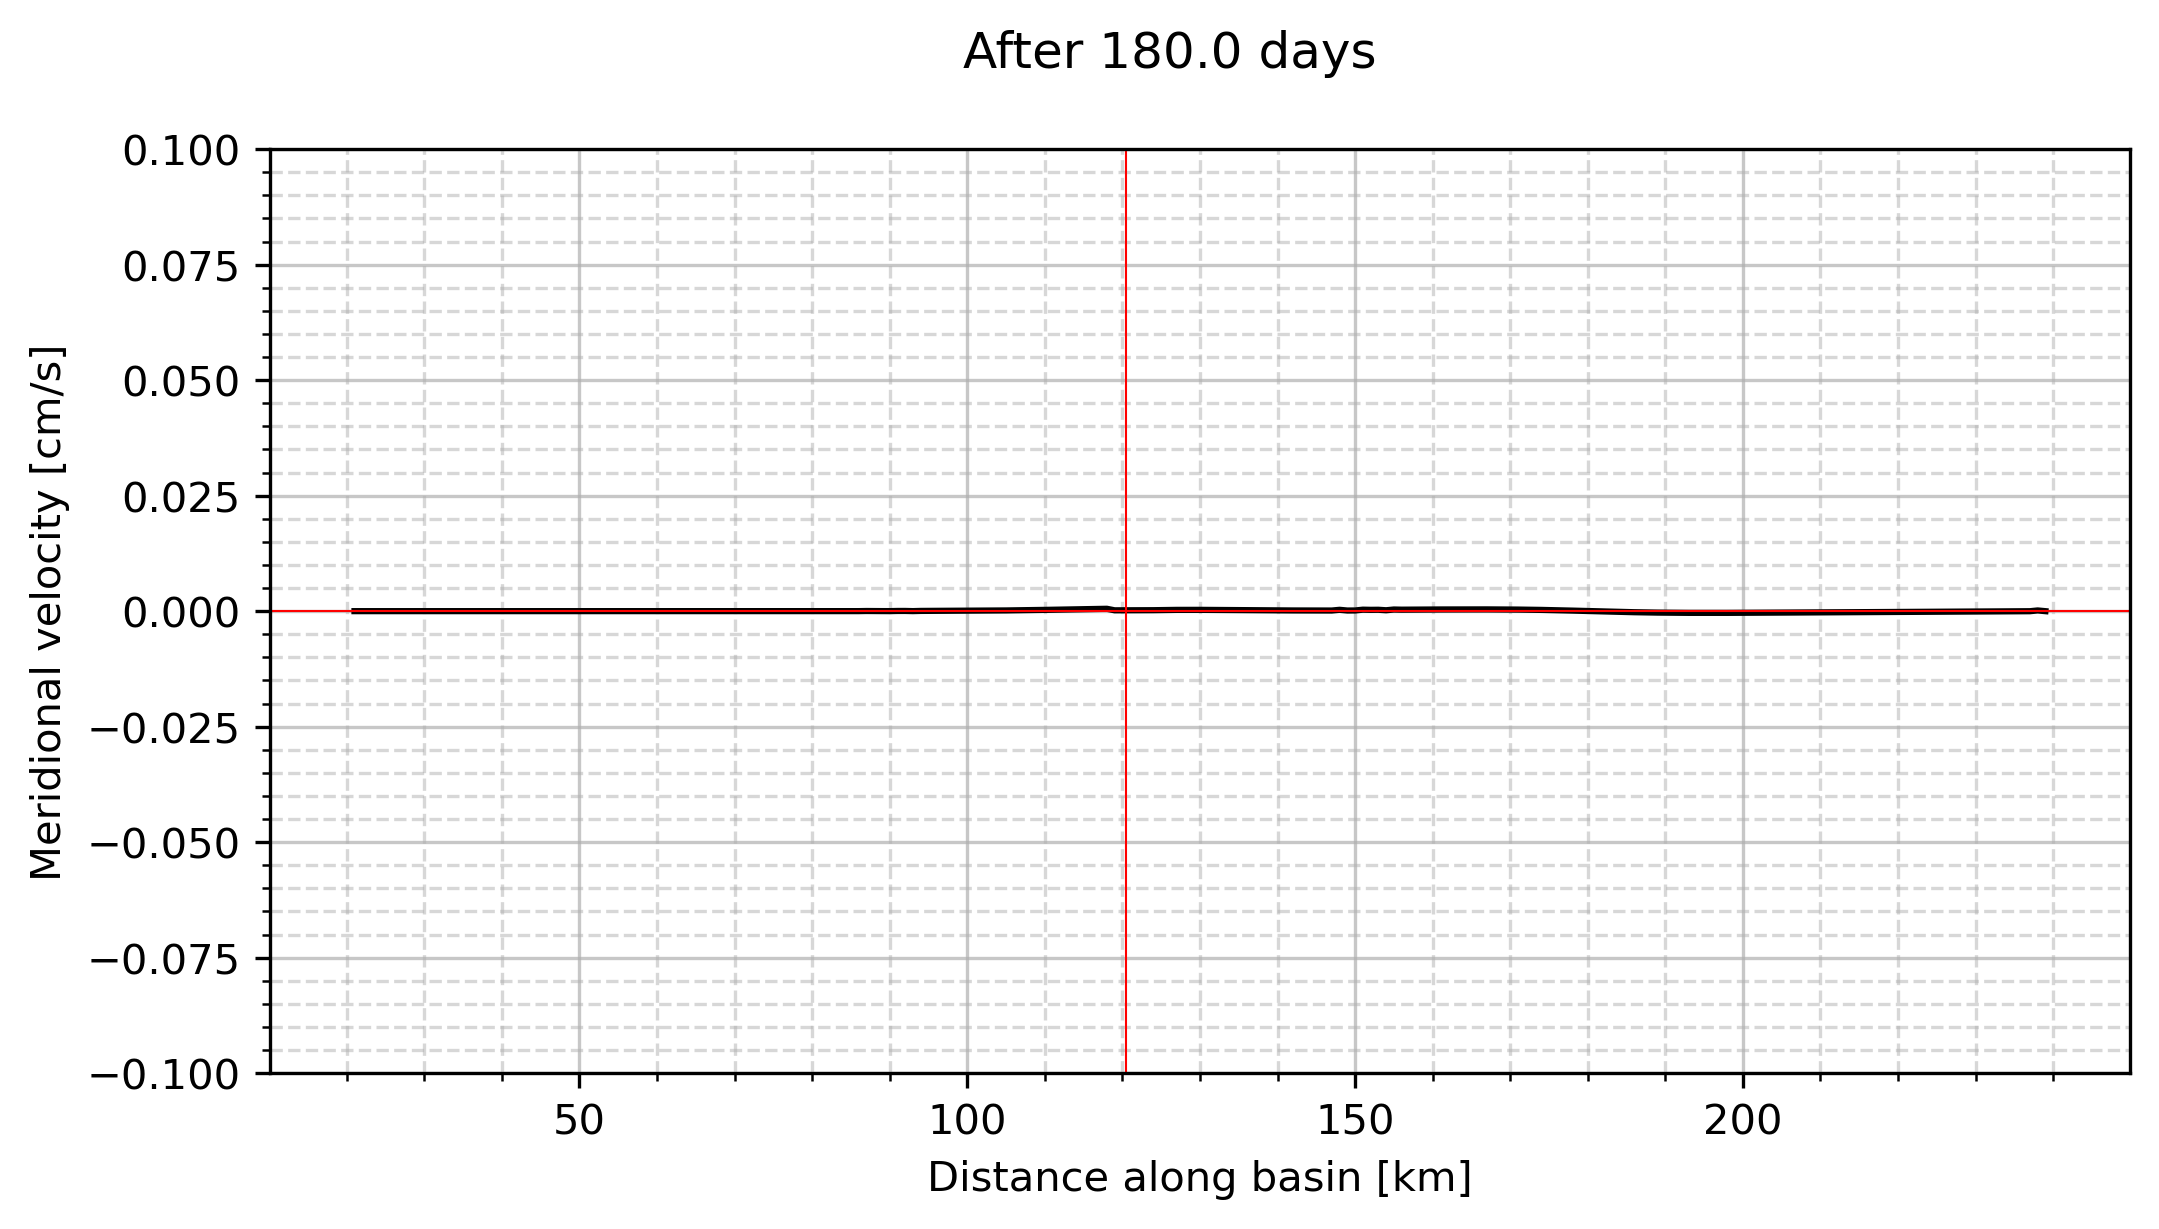

In [13]:
fig,ax=plt.subplots()
pax,=ax.plot(ds.Yp1[OB:OBend]/1000,velout[tinmerid,OB:OBend]*100,color='k')
ax.set(ylabel='Meridional velocity [cm/s]',xlabel='Distance along basin [km]')

tt=(1+tinmerid)*((ds.T.values[1]-ds.T.values[0])/(60*60*24))
fig.suptitle(f'After {tt:.1f} days')
    
ax.minorticks_on()

ax.grid(which='minor',linestyle='--', alpha=0.5)
ax.grid(which='major',alpha=0.7)

ax.axvline(ds.Y[int(len(ds.Y)/2)]/1000,linewidth=0.5,color='red')
ax.axhline(0,linewidth=0.5,color='red')
ax.set_ylim((-0.1,0.1))
anim = FuncAnimation(fig, animateLine,frames=len(ds.T.values)-tinmerid, repeat=False)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'MeridVel.mp4', writer=writer, dpi=600)

